In [1]:
import logging

# Stop PrimAITE logs
logging.disable(logging.CRITICAL)

## Load LLM

In [2]:
from primaite.agents.aegis.modules.llm import LLM
from peft import LoraConfig

default_peft_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=64,
    lora_dropout=0.1,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "wte"],
    lora_alpha=32,
)
llm = LLM(peft_config=default_peft_config)

/home/jonathan/projects/primaite/PrimAITE/aegis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Trainable LLM parameters: 25,165,824
All LLM parameters: 931,235,840
Percentage of trainable LLM parameters: 2.70%%


## Load PrimAITE    

In [3]:
from primaite.agents.agent_abc import get_session_path
from primaite.environment.primaite_env import Primaite
from datetime import datetime

timestamp_str = datetime.now()

env = Primaite(
    training_config_path="../agents/training_configs/git.yaml",
    lay_down_config_path="../data/laydown_configs/lay_down_config_6_data_manipulation.yaml",
    session_path=get_session_path(timestamp_str),
    timestamp_str=timestamp_str,
)

{'item_type': 'RED_POL', 'id': '50', 'start_step': 50, 'end_step': 50, 'targetNodeId': '1', 'initiator': 'DIRECT', 'type': 'SERVICE', 'protocol': 'UDP', 'state': 'COMPROMISED', 'sourceNodeId': 'NA', 'sourceNodeService': 'NA', 'sourceNodeServiceState': 'NA'}
{'item_type': 'RED_POL', 'id': '52', 'start_step': 100, 'end_step': 100, 'targetNodeId': '8', 'initiator': 'IER', 'type': 'SERVICE', 'protocol': 'UDP', 'state': 'COMPROMISED', 'sourceNodeId': 'NA', 'sourceNodeService': 'NA', 'sourceNodeServiceState': 'NA'}
{'item_type': 'RED_POL', 'id': '53', 'start_step': 105, 'end_step': 105, 'targetNodeId': '8', 'initiator': 'SERVICE', 'type': 'FILE', 'protocol': 'NA', 'state': 'CORRUPT', 'sourceNodeId': '8', 'sourceNodeService': 'UDP', 'sourceNodeServiceState': 'COMPROMISED'}
{'item_type': 'RED_POL', 'id': '54', 'start_step': 105, 'end_step': 105, 'targetNodeId': '8', 'initiator': 'SERVICE', 'type': 'SERVICE', 'protocol': 'TCP_SQL', 'state': 'COMPROMISED', 'sourceNodeId': '8', 'sourceNodeService

<Figure size 640x480 with 0 Axes>

## Generating Training Data

In [4]:
from primaite.network.network import Network
from primaite.agents.utils import from_networkx, prepare_graph
from torch_geometric.data import Data
import torch


# Creates graph from Primaite
def create_graph(env: Primaite, obs) -> Data:
    """Construct a graph from the observation space, using only the node features"""
    graph = prepare_graph(env.network)
    state = from_networkx(graph)
    state.x = torch.tensor(obs[: env.num_nodes, 1:], dtype=torch.float32).to("cuda:0")
    return state


# Creates very compact text representation from Primaite
def text_repr(env):
    network = Network.from_env(env)
    env_dict = network.nodes_table().to_dict()

    node_names = list(env_dict["Name"].values())
    compact_env_dict = {node_name: dict() for node_name in node_names}

    for header, value_dict in env_dict.items():
        if header == "Name":
            continue

        for node_key, value in value_dict.items():
            if value != "GOOD" and value != "-":
                compact_env_dict[node_names[node_key - 1]][header] = value

    return repr(compact_env_dict)

In [5]:
from torch_geometric.data import Batch
from tqdm import tqdm


# Generate PrimAITE graphs by taking random actions
def generate_data(env, num_env_restarts: int = 10, num_steps_per_env: int = 50, progress_bar: bool = False) -> Batch:

    graphs = []
    texts = []

    for _ in tqdm(range(num_env_restarts), disable=not progress_bar, desc="Simulating Env"):
        env.reset()

        for _ in range(num_steps_per_env):
            obvs, reward, done, info = env.step(env.action_space.sample())

            if done:
                break

            text_representation = text_repr(env)
            if text_representation not in texts:
                graphs.append(create_graph(env, obvs).cuda())
                texts.append(text_representation)

    text_embeddings = [llm.generate_last_state(texts=[text], grad=False) for text in tqdm(texts)]
    for graph, embedding in zip(graphs, text_embeddings):
        graph.text_embed = embedding

    batch = Batch.from_data_list(graphs)

    print(f"\nGenerated {batch.batch_size} examples from a possible {num_env_restarts * num_steps_per_env}\n")
    return batch

In [6]:
from tqdm import tqdm
import torch.nn as nn
import torch
from torch_geometric.loader import DataLoader
import numpy as np

# Define train/val/test splits
val_split = 0.05
test_split = 0.1

# Generate Dataset
dataset = generate_data(env, num_env_restarts=20, num_steps_per_env=200, progress_bar=True)

indicies = np.arange(dataset.batch_size)
np.random.shuffle(indicies)

val_idx = int(dataset.batch_size * val_split)
test_idx = int(dataset.batch_size * test_split)

dataset = dataset.to_data_list()

train_dataset = Batch.from_data_list(dataset[val_idx + test_idx :])
val_dataset = Batch.from_data_list(dataset[:val_idx])
test_dataset = Batch.from_data_list(dataset[val_idx : val_idx + test_idx])

# As the LLM is only needed to generate the datasets, remove it and free up GPU memory
del llm
torch.cuda.empty_cache()

  0%|          | 0/1929 [00:00<?, ?it/s]/home/jonathan/projects/primaite/PrimAITE/src/primaite/agents/aegis/modules/llm.py:441: UserWarning: _generate_last_state has not been tested since a substantial update to the LLM class!
It may not work as intended!
  warnings.warn(
2024-09-29 12:50:48.260516: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-29 12:50:48.307985: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-29 12:50:49.057049: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
100%|██████████| 1929/1929 [02:42<00:00, 11.89it/s]



Generated 1929 examples from a possible 4000



## Load Graph Embeddings Model

In [7]:
from primaite.agents.aegis.modules.ge import GraphEmbedding

graph_embeddings_model = GraphEmbedding(
    in_channels=6,
    output_dim=2048,
    hidden_dim=4096,
    n_gat_layers=3,
    n_tokens=1,
).to("cuda:0")

#### Define Training Parameters

In [8]:
train_loss_history = []
val_loss_history = []

optimiser = torch.optim.Adam(graph_embeddings_model.parameters(), lr=0.001)

n_epochs = 100
batch_size = 256

dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

## Main Training Loop

In [9]:
for epoch in (pbar := tqdm(range(n_epochs))):
    for batch in dataloader:
        optimiser.zero_grad()

        graph_embeddings = graph_embeddings_model(batch).squeeze().half()

        # Caclulate cosine similarity by first normalising each vector, then computing dot product
        te_norm = batch.text_embed / batch.text_embed.norm(dim=1).unsqueeze(1)
        ge_norm = graph_embeddings / graph_embeddings.norm(dim=1).unsqueeze(1)

        # Calculate the loss by fiding the absolute difference between the text embeddings similarities and the text and graph sims
        loss = torch.mean(torch.abs(te_norm @ ge_norm.T - te_norm @ te_norm.T))

        loss.backward()
        optimiser.step()

        pbar.set_description(f"Loss: {loss:6.6}")
        train_loss_history.append(loss.item())

    # Calculate val loss every epoch
    with torch.no_grad():
        graph_embeddings = graph_embeddings_model(val_dataset).squeeze().half()
        te_norm = val_dataset.text_embed / val_dataset.text_embed.norm(dim=1).unsqueeze(1)
        ge_norm = graph_embeddings / graph_embeddings.norm(dim=1).unsqueeze(1)
        val_loss_history.append(torch.mean(torch.abs(te_norm @ ge_norm.T - te_norm @ te_norm.T)).item())

Loss: 0.120178: 100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


(0.0, 1.0429931640625)

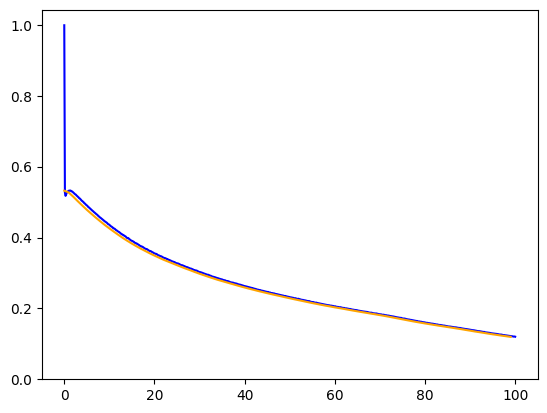

In [10]:
import matplotlib.pyplot as plt

# Note: if the text embeddings are all roughly the same, the matching and non-matching loss will just add to some number.
plt.plot(np.linspace(0, n_epochs, len(dataloader) * n_epochs), train_loss_history, color="blue")
plt.plot(np.arange(n_epochs), val_loss_history, color="orange")
plt.ylim(bottom=0)

## Extra - Measuring Diversity of Text Embeddings

In [11]:
# Mean over std of each element in text embeddings (close to 0 bad)
torch.mean(torch.std(train_dataset.text_embed.view(-1, 2048), axis=0)).item()

0.036834716796875

In [12]:
# Computes average cosine similarity between all pairs of different embeddings (1 bad, 0 good)
text_embeddings = train_dataset.text_embed.view(-1, 2048).cpu()
text_embeddings = text_embeddings / text_embeddings.norm(dim=1).unsqueeze(1)
sims = torch.triu(text_embeddings @ text_embeddings.T, diagonal=1)
avg_sim = torch.sum(sims, dtype=torch.float32) / ((sims.shape[0] ** 2 - sims.shape[0]) / 2)

avg_sim.item()

0.9988729357719421

## Test Loss

In [13]:
graph_embeddings = graph_embeddings_model(test_dataset).squeeze().half()

# Caclulate cosine similarity by first normalising each vector, then computing dot product
te_norm = test_dataset.text_embed / test_dataset.text_embed.norm(dim=1).unsqueeze(1)
ge_norm = graph_embeddings / graph_embeddings.norm(dim=1).unsqueeze(1)

# Calculate the loss by fiding the absolute difference between the text embeddings similarities and the text and graph sims
torch.mean(torch.abs(te_norm @ ge_norm.T - te_norm @ te_norm.T))

tensor(0.1197, device='cuda:0', dtype=torch.float16, grad_fn=<MeanBackward0>)